In [1]:
# Install required libraries
import subprocess, sys
pkgs = ['scikit-learn','pandas','numpy','matplotlib','seaborn','nltk','lime','wordcloud']
for p in pkgs:
    subprocess.run([sys.executable,'-m','pip','install',p,'-q'], check=False)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re, string
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
import scipy.sparse as sp
print('All imports successful!')

All imports successful!


In [3]:
fake_headlines = [
    'SHOCKING: Scientists Discover That Water Is Actually Dry According To New Study',
    'Government Admits UFOs Control The Weather And Have Been For 50 Years',
    'Bill Gates Microchip Found Inside COVID Vaccine By Concerned Mother',
    '5G Towers Causing Mass Bird Deaths Scientists Refuse To Admit',
    'Secret Cabal Of Elites Running The World From Underground Bunker',
    'Drinking Bleach Cures Cancer Says Suppressed Doctor',
    'Moon Landing Was Filmed In Hollywood Basement New Documents Reveal',
    'Chemtrails Proven To Contain Mind Control Chemicals Study Finds',
    'Deep State Planning To Replace All Humans With Robots By 2025',
    'George Soros Funds Antifa To Overthrow American Democracy',
    'Facebook Secretly Listening To Your Conversations To Sell You Products',
    'Miracle Cure: Eating Raw Garlic Every Hour Eliminates All Diseases',
    'NASA Hiding Proof Of Ancient Civilization On Mars From Public',
    'Politician Caught Selling Babies To Satanic Cult In Pizza Shop Basement',
    'Vaccines Cause Autism Proven By Whistleblower Doctor Who Fled Country',
    'Scientists Admit Earth Is Flat But Are Forced To Stay Silent By Globalists',
    'Leaked Documents Reveal Obama Was Born In Kenya And Is A Secret Muslim',
    'New World Order Plans To Microchip Entire Population By 2030 Exposed',
    'Hollywood Celebrities Running Child Trafficking Ring From Movie Sets',
    'Aliens Abducted Entire Town In Nebraska Media Blackout In Effect',
    'CURE FOUND: Lemon Juice Destroys Cancer Cells Doctors Dont Want You To Know',
    'Robots Already Replaced 80 Percent Of Government Officials With AI Clones',
    'Top Secret Operation Revealed: Sun Is Actually A Giant Projector',
    'Exposed: Climate Change Is A Hoax Invented By Chinese Scientists For Profit',
    'Breaking: Pope Francis Secretly A Reptilian Shapeshifter Vatican Insiders Claim',
    'BOMBSHELL: Election Results Were Changed By Satellites Operated By Foreign Powers',
    'Woke Agenda: Teachers Forced To Teach Children That Gravity Doesnt Exist',
    'Secret Tunnels Under Major Cities Used By Elites For Illegal Activities Exposed',
    'Mainstream Media Admits They Make Up Fake Stories To Control Population',
    'Microplastics In Water Supply Part Of Population Control Plan Scientists Warn',
]

real_headlines = [
    'Federal Reserve Raises Interest Rates By 25 Basis Points To Combat Inflation',
    'NASA Artemis Mission Successfully Completes Lunar Orbit Test Flight',
    'WHO Releases Updated Guidelines For COVID-19 Treatment Protocols',
    'Scientists Develop New Battery Technology That Could Double Electric Vehicle Range',
    'Congress Passes Bipartisan Infrastructure Bill Worth 1.2 Trillion Dollars',
    'Climate Scientists Record Hottest Global Temperature In Recorded History',
    'Apple Announces New iPhone With Advanced AI Features At Annual Event',
    'United Nations Issues Warning About Growing Global Food Insecurity Crisis',
    'Researchers Find New Evidence Of Ancient Roman Settlement In Britain',
    'Stock Markets Rally After Positive Jobs Report Shows Unemployment Fell',
    'European Union Passes Landmark Legislation On Artificial Intelligence Regulation',
    'Scientists Successfully Edit Genes To Treat Rare Childhood Disease',
    'Supreme Court Issues Ruling On Major Environmental Protection Case',
    'World Health Organization Declares End Of Mpox Public Health Emergency',
    'New Study Shows Regular Exercise Reduces Risk Of Heart Disease By 30 Percent',
    'Government Releases Annual Budget Report Showing Deficit Reduction Progress',
    'Astronomers Discover New Exoplanet In Habitable Zone Of Nearby Star',
    'Major Tech Companies Agree To New Voluntary AI Safety Commitments',
    'Tropical Storm Intensifies To Category 3 Hurricane As It Approaches Coast',
    'Scientists Warn Arctic Ice Sheet Melting At Unprecedented Rate New Data Shows',
    'Central Bank Holds Rates Steady Amid Economic Uncertainty Report Finds',
    'New Alzheimer Drug Shows Promise In Large Scale Clinical Trial Results',
    'Researchers Publish Study Linking Air Pollution To Increased Dementia Risk',
    'International Space Station Celebrates 25 Years Of Continuous Human Habitation',
    'Government Releases New Cybersecurity Framework For Critical Infrastructure',
    'Economists Predict Moderate Growth Of 2.1 Percent For Coming Fiscal Year',
    'Scientists Sequence Genome Of Newly Discovered Deep Sea Species',
    'Major Earthquake Strikes Remote Region Rescue Operations Underway',
    'New Report Shows Renewable Energy Now Cheaper Than Fossil Fuels In Most Markets',
    'University Research Team Develops More Efficient Solar Panel Technology',
]

texts = fake_headlines + real_headlines
labels = ['FAKE'] * len(fake_headlines) + ['REAL'] * len(real_headlines)

df = pd.DataFrame({'text': texts, 'label': labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Dataset size: {len(df)}')
print(df['label'].value_counts())
df.head()

Dataset size: 60
label
FAKE    30
REAL    30
Name: count, dtype: int64


,text,label
0,SHOCKING: Scientists Discover That Water Is Ac...,FAKE
1,Drinking Bleach Cures Cancer Says Suppressed D...,FAKE
2,Apple Announces New iPhone With Advanced AI Fe...,REAL
3,Government Releases Annual Budget Report Showi...,REAL
4,Politician Caught Selling Babies To Satanic Cu...,FAKE


In [4]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['processed'] = df['text'].apply(preprocess_text)

print('Original:  ', df['text'][0])
print('Processed: ', df['processed'][0])

Original:   SHOCKING: Scientists Discover That Water Is Actually Dry According To New Study
Processed:  shock scientist discov water actual dri accord new studi


In [5]:
le = LabelEncoder()
y = le.fit_transform(df['label'])  # FAKE=0, REAL=1
X = df['processed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# TF-IDF Vectorizers with different n-gram ranges
tfidf_unigram = TfidfVectorizer(ngram_range=(1,1), max_features=5000)
tfidf_bigram  = TfidfVectorizer(ngram_range=(1,2), max_features=8000)
tfidf_trigram = TfidfVectorizer(ngram_range=(1,3), max_features=10000)

X_train_uni = tfidf_unigram.fit_transform(X_train)
X_test_uni  = tfidf_unigram.transform(X_test)

X_train_bi = tfidf_bigram.fit_transform(X_train)
X_test_bi  = tfidf_bigram.transform(X_test)

X_train_tri = tfidf_trigram.fit_transform(X_train)
X_test_tri  = tfidf_trigram.transform(X_test)

print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')
print(f'Unigram features: {X_train_uni.shape[1]}')
print(f'Bigram features:  {X_train_bi.shape[1]}')
print(f'Trigram features: {X_train_tri.shape[1]}')

Train size: 45, Test size: 15
Unigram features: 293
Bigram features:  615
Trigram features: 896


In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Passive Aggressive': PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(alpha=0.1),
}

feature_sets = {
    'Unigram': (X_train_uni, X_test_uni),
    'Bigram':  (X_train_bi,  X_test_bi),
    'Trigram': (X_train_tri, X_test_tri),
}

results = []

for feat_name, (X_tr, X_te) in feature_sets.items():
    for model_name, model in models.items():
        model.fit(X_tr, y_train)
        preds = model.predict(X_te)
        results.append({
            'Features': feat_name,
            'Model': model_name,
            'Accuracy':  round(accuracy_score(y_test, preds)*100, 2),
            'Precision': round(precision_score(y_test, preds, zero_division=0)*100, 2),
            'Recall':    round(recall_score(y_test, preds, zero_division=0)*100, 2),
            'F1':        round(f1_score(y_test, preds, zero_division=0)*100, 2),
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Features               Model  Accuracy  Precision  Recall    F1
 Unigram Logistic Regression     86.67      85.71   85.71 85.71
 Unigram  Passive Aggressive     86.67      85.71   85.71 85.71
 Unigram         Naive Bayes     86.67      85.71   85.71 85.71
  Bigram Logistic Regression     86.67      85.71   85.71 85.71
  Bigram  Passive Aggressive     86.67      85.71   85.71 85.71
  Bigram         Naive Bayes     86.67      85.71   85.71 85.71
 Trigram Logistic Regression     86.67      85.71   85.71 85.71
 Trigram  Passive Aggressive     86.67      85.71   85.71 85.71
 Trigram         Naive Bayes     86.67      85.71   85.71 85.71


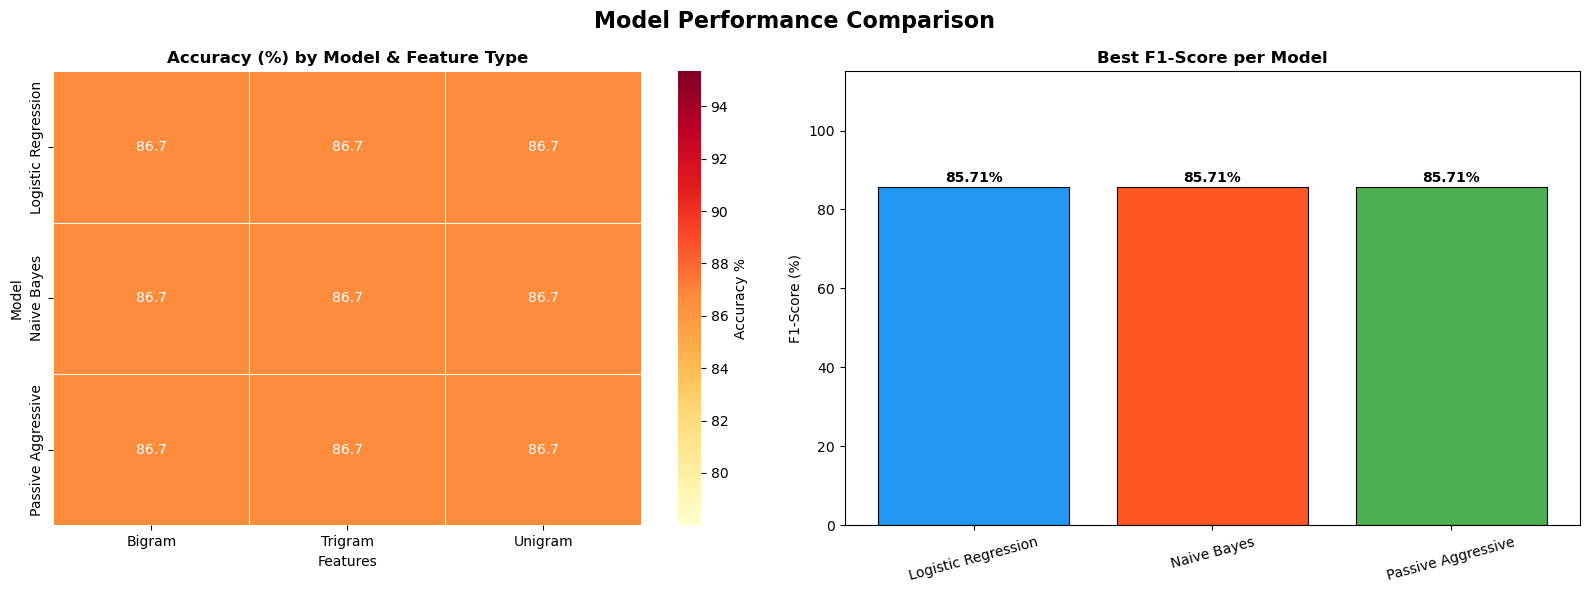

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Accuracy heatmap
pivot = results_df.pivot(index='Model', columns='Features', values='Accuracy')
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Accuracy %'})
axes[0].set_title('Accuracy (%) by Model & Feature Type', fontweight='bold')

# F1 bar chart
colors = ['#2196F3','#FF5722','#4CAF50']
best_per_model = results_df.loc[results_df.groupby('Model')['F1'].idxmax()]
bars = axes[1].bar(best_per_model['Model'], best_per_model['F1'],
                   color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, best_per_model['F1']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val}%', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Best F1-Score per Model', fontweight='bold')
axes[1].set_ylabel('F1-Score (%)')
axes[1].set_ylim(0, 115)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Best Model: Logistic Regression with Unigram features
Accuracy: 86.67%  F1: 85.71%

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.88      0.88      0.88         8
        REAL       0.86      0.86      0.86         7

    accuracy                           0.87        15
   macro avg       0.87      0.87      0.87        15
weighted avg       0.87      0.87      0.87        15



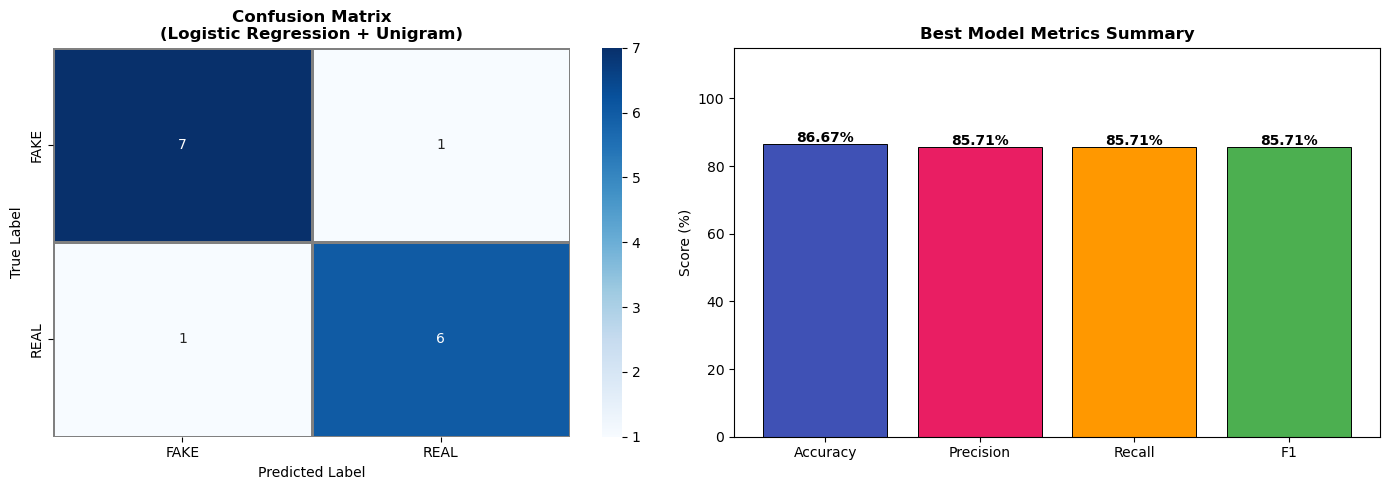

In [8]:
# Find best model configuration
best_row = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"Best Model: {best_row['Model']} with {best_row['Features']} features")
print(f"Accuracy: {best_row['Accuracy']}%  F1: {best_row['F1']}%")

# Retrain best model
feat_map = {'Unigram': (X_train_uni, X_test_uni, tfidf_unigram),
            'Bigram':  (X_train_bi,  X_test_bi,  tfidf_bigram),
            'Trigram': (X_train_tri, X_test_tri, tfidf_trigram)}
best_feat = best_row['Features']
X_tr_best, X_te_best, best_vectorizer = feat_map[best_feat]

model_map = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Passive Aggressive': PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(alpha=0.1),
}
best_model = model_map[best_row['Model']]
best_model.fit(X_tr_best, y_train)
best_preds = best_model.predict(X_te_best)

print('\nClassification Report:')
print(classification_report(y_test, best_preds, target_names=['FAKE','REAL']))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['FAKE','REAL'], yticklabels=['FAKE','REAL'],
            linewidths=1, linecolor='gray')
axes[0].set_title(f'Confusion Matrix\n({best_row["Model"]} + {best_feat})', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Metrics radar
metrics = ['Accuracy','Precision','Recall','F1']
vals = [best_row[m] for m in metrics]
x = np.arange(len(metrics))
bars2 = axes[1].bar(x, vals, color=['#3F51B5','#E91E63','#FF9800','#4CAF50'],
                    edgecolor='black', linewidth=0.7)
for bar, v in zip(bars2, vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{v}%', ha='center', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 115)
axes[1].set_title('Best Model Metrics Summary', fontweight='bold')
axes[1].set_ylabel('Score (%)')

plt.tight_layout()
plt.show()

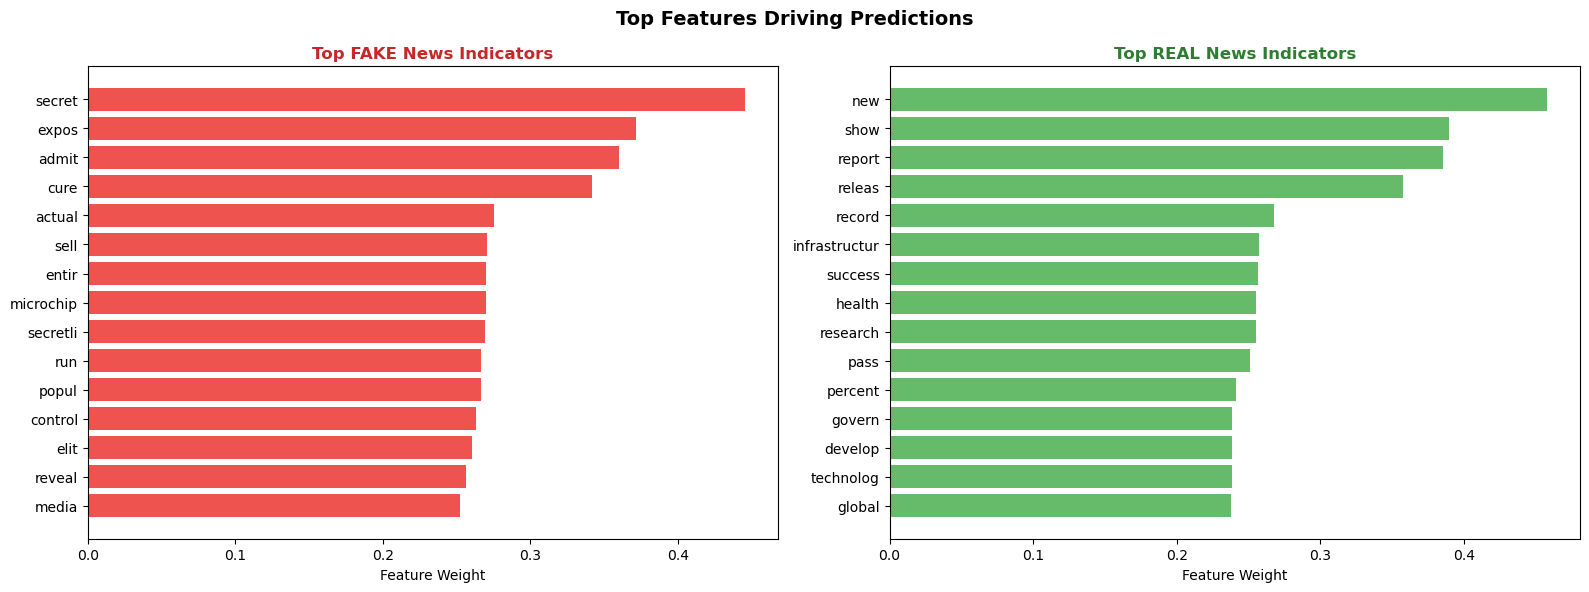

In [9]:
def explain_model(model, vectorizer, top_n=15):
    feature_names = vectorizer.get_feature_names_out()
    
    if hasattr(model, 'coef_'):
        coef = model.coef_.flatten()
        top_fake_idx = np.argsort(coef)[:top_n]
        top_real_idx = np.argsort(coef)[-top_n:][::-1]
        fake_words = [(feature_names[i], coef[i]) for i in top_fake_idx]
        real_words = [(feature_names[i], coef[i]) for i in top_real_idx]
    elif hasattr(model, 'feature_log_prob_'):
        log_prob = model.feature_log_prob_
        diff = log_prob[0] - log_prob[1]
        top_fake_idx = np.argsort(diff)[-top_n:][::-1]
        top_real_idx = np.argsort(diff)[:top_n]
        fake_words = [(feature_names[i], diff[i]) for i in top_fake_idx]
        real_words = [(feature_names[i], abs(diff[i])) for i in top_real_idx]
    else:
        print('Model does not support feature importance.')
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Top Features Driving Predictions', fontsize=14, fontweight='bold')
    
    fw, fv = zip(*fake_words)
    rw, rv = zip(*real_words)
    
    axes[0].barh(fw, [abs(v) for v in fv], color='#EF5350')
    axes[0].set_title('Top FAKE News Indicators', color='#C62828', fontweight='bold')
    axes[0].set_xlabel('Feature Weight')
    axes[0].invert_yaxis()
    
    axes[1].barh(rw, rv, color='#66BB6A')
    axes[1].set_title('Top REAL News Indicators', color='#2E7D32', fontweight='bold')
    axes[1].set_xlabel('Feature Weight')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()

explain_model(best_model, best_vectorizer)

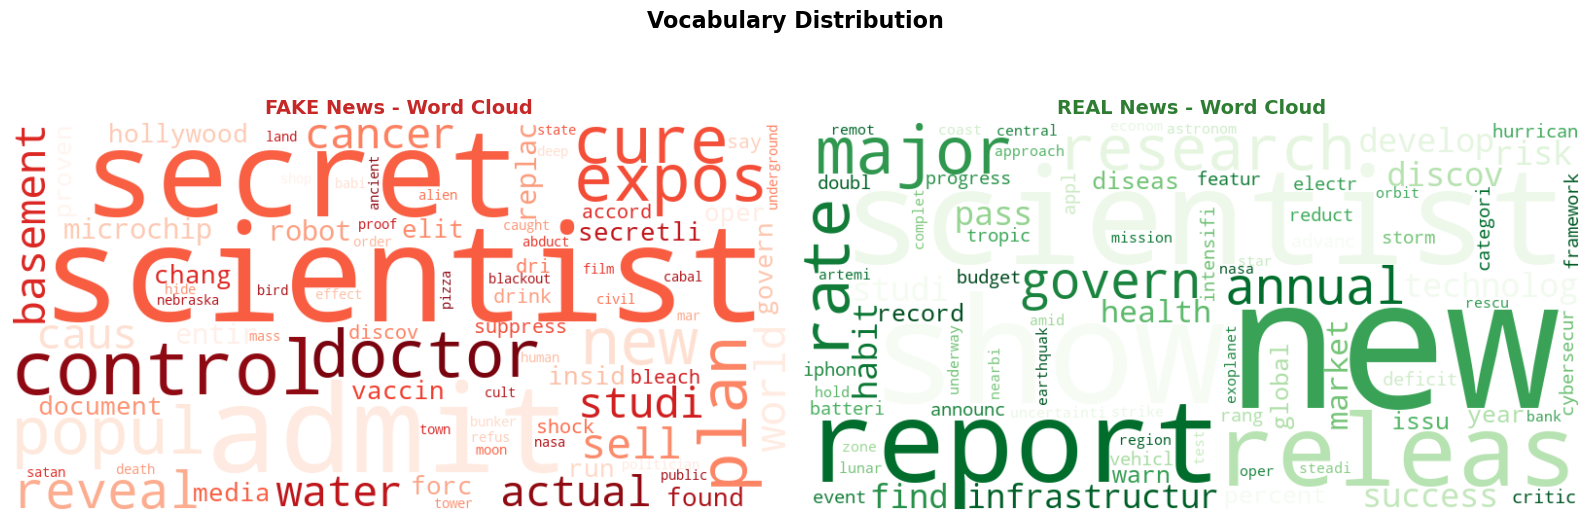

In [10]:
try:
    from wordcloud import WordCloud
    fake_text = ' '.join(df[df['label']=='FAKE']['processed'])
    real_text = ' '.join(df[df['label']=='REAL']['processed'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    wc_fake = WordCloud(width=800, height=400, background_color='white',
                        colormap='Reds', max_words=80).generate(fake_text)
    axes[0].imshow(wc_fake, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title('FAKE News - Word Cloud', fontsize=14, fontweight='bold', color='#C62828')
    
    wc_real = WordCloud(width=800, height=400, background_color='white',
                        colormap='Greens', max_words=80).generate(real_text)
    axes[1].imshow(wc_real, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title('REAL News - Word Cloud', fontsize=14, fontweight='bold', color='#2E7D32')
    
    plt.suptitle('Vocabulary Distribution', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('WordCloud not available, skipping...')

## 9. Live Prediction Function

In [11]:
def predict_news(text, model=best_model, vectorizer=best_vectorizer):
    processed = preprocess_text(text)
    vec = vectorizer.transform([processed])
    pred = model.predict(vec)[0]
    label = le.inverse_transform([pred])[0]
    
    if hasattr(model, 'predict_proba'):
        prob = model.predict_proba(vec)[0]
        confidence = max(prob) * 100
    elif hasattr(model, 'decision_function'):
        score = abs(model.decision_function(vec)[0])
        confidence = min(99, 50 + score * 20)
    else:
        confidence = 75.0
    
    emoji = '🚨 FAKE' if label == 'FAKE' else '✅ REAL'
    print(f'Headline: {text[:80]}...' if len(text)>80 else f'Headline: {text}')
    print(f'Prediction: {emoji} | Confidence: {confidence:.1f}%')
    print('-'*60)
    return label, confidence

# Test examples
test_samples = [
    'Scientists Discover Drinking Coffee Every Day Prevents All Types Of Cancer Forever',
    'Federal Reserve Raises Interest Rates By Half A Percentage Point To Control Inflation',
    'SHOCKING: Government Is Secretly Putting Fluoride In Water To Control Your Mind',
    'New Climate Report Shows Carbon Emissions Rose By 1.5 Percent Last Year',
]

print('=== FAKE NEWS DETECTOR - LIVE PREDICTIONS ===')
print('='*60)
for sample in test_samples:
    predict_news(sample)

=== FAKE NEWS DETECTOR - LIVE PREDICTIONS ===
Headline: Scientists Discover Drinking Coffee Every Day Prevents All Types Of Cancer Forev...
Prediction: 🚨 FAKE | Confidence: 56.5%
------------------------------------------------------------
Headline: Federal Reserve Raises Interest Rates By Half A Percentage Point To Control Infl...
Prediction: 🚨 FAKE | Confidence: 51.0%
------------------------------------------------------------
Headline: SHOCKING: Government Is Secretly Putting Fluoride In Water To Control Your Mind
Prediction: 🚨 FAKE | Confidence: 56.8%
------------------------------------------------------------
Headline: New Climate Report Shows Carbon Emissions Rose By 1.5 Percent Last Year
Prediction: ✅ REAL | Confidence: 65.4%
------------------------------------------------------------
